In [1]:
"""
Анализ статистики шума стохастического градиента
=================================================

Цель: проверить гипотезу о гауссовости шума стохастического градиента.

МЕТОДОЛОГИЧЕСКОЕ ЗАМЕЧАНИЕ:
---------------------------
Анализ 2-нормы разности ||∇f_batch - ∇f_full||_2 методологически некорректен
для проверки гауссовости, так как:
1. Норма — это скаляр, полученный из многомерного вектора
2. По ЦПТ, норма гауссовского вектора имеет распределение χ (хи), а не Gaussian
3. Норма уничтожает информацию о хвостах распределения в отдельных компонентах

Корректный подход — анализ одномерных проекций шума на случайные направления.
Если шум гауссовский, то его проекции на любое направление также гауссовские.
Если шум имеет α-stable распределение с α < 2, то проекции также α-stable.

ТЕОРЕТИЧЕСКИЙ КОНТЕКСТ:
-----------------------
α-stable распределения — единственный класс распределений, устойчивых относительно
суммирования независимых случайных величин (обобщённая ЦПТ).
- α = 2 соответствует Gaussian распределению
- α < 2 означает тяжёлые хвосты (power-law decay)
- При α < 2 дисперсия бесконечна, что имеет важные следствия для SGD

Если α < 2, то:
- Стандартные предположения о сходимости SGD нарушаются
- Требуются модифицированные оценки скорости сходимости
- Шум SGD не может быть аппроксимирован гауссовской диффузией
"""

import torch
from torch.utils.data import Subset, DataLoader
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, levy_stable, probplot

repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(repo_root)

from tqdm import tqdm

from src.utils import MNIST
from src.model import MLP

# =============================================================================
# ОГРАНИЧЕНИЕ РАЗМЕРА ВЫБОРКИ
# =============================================================================
# Используем подвыборку из 6000 примеров вместо полных 60000
# Это ускоряет вычисления и достаточно для статистического анализа
SAMPLE_SIZE = 6000

In [2]:
# =============================================================================
# ФУНКЦИИ ДЛЯ ВЫЧИСЛЕНИЯ ГРАДИЕНТОВ
# =============================================================================

def compute_full_gradient(model, train_loader, criterion, device):
    """
    Вычисляет эмпирический полный градиент как среднее градиентов по всем батчам.
    
    Полный градиент:
        ∇f(θ) = (1/N) Σᵢ ∇fᵢ(θ)
    
    где N — число примеров в обучающей выборке.
    
    ВАЖНО: Модель переводится в train() режим, но веса НЕ обновляются.
    Оптимизатор используется только для zero_grad().
    
    Args:
        model: PyTorch модель
        train_loader: DataLoader с обучающими данными
        criterion: функция потерь
        device: устройство (cpu/cuda/mps)
    
    Returns:
        torch.Tensor: flatten-вектор полного градиента по всем параметрам
    """
    model.train()
    full_grad_accumulator = None
    num_batches = 0
    
    for images, labels in tqdm(train_loader, desc="Computing full gradient"):
        images, labels = images.to(device), labels.to(device)
        model.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Собираем градиент в flatten-вектор
        batch_grad = torch.cat([p.grad.flatten() for p in model.parameters()])
        
        if full_grad_accumulator is None:
            full_grad_accumulator = batch_grad.clone()
        else:
            full_grad_accumulator += batch_grad
        
        num_batches += 1
    
    # Усредняем по числу батчей
    full_grad = full_grad_accumulator / num_batches
    
    return full_grad


def stochastic_gradient_sampling(model, train_loader, criterion, device, full_grad):
    """
    Вычисляет шум стохастического градиента для каждого батча.
    
    Шум определяется как:
        ξ_batch = ∇f_batch(θ) - ∇f(θ)
    
    где:
        - ∇f_batch(θ) — градиент на отдельном батче
        - ∇f(θ) — полный градиент (среднее по всему датасету)
    
    МЕТОДОЛОГИЧЕСКОЕ ЗАМЕЧАНИЕ:
    ---------------------------
    Мы сохраняем ПОЛНЫЙ ВЕКТОР шума, а не его норму.
    Это критически важно для корректного статистического анализа:
    - Норма уничтожает информацию о распределении отдельных компонент
    - Анализ нормы не позволяет различить Gaussian и heavy-tailed распределения
    - Для проверки гауссовости необходимо анализировать одномерные проекции
    
    Args:
        model: PyTorch модель
        train_loader: DataLoader с обучающими данными
        criterion: функция потерь
        device: устройство
        full_grad: предвычисленный полный градиент (torch.Tensor)
    
    Returns:
        list[torch.Tensor]: список векторов шума для каждого батча
    """
    model.train()
    noise_vectors = []
    
    for images, labels in tqdm(train_loader, desc="Sampling stochastic gradients"):
        images, labels = images.to(device), labels.to(device)
        model.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Собираем стохастический градиент в flatten-вектор
        stochastic_grad = torch.cat([p.grad.flatten() for p in model.parameters()])
        
        # Вычисляем шум как разность
        noise = stochastic_grad - full_grad
        
        noise_vectors.append(noise.cpu())  # Переносим на CPU для экономии памяти GPU
    
    return noise_vectors


In [3]:
# =============================================================================
# ФУНКЦИИ ДЛЯ АНАЛИЗА ОДНОМЕРНЫХ ПРОЕКЦИЙ
# =============================================================================

def project_noise(noise_vectors, direction=None):
    """
    Проецирует векторы шума на одномерное направление.
    
    ТЕОРЕТИЧЕСКОЕ ОБОСНОВАНИЕ:
    --------------------------
    Для проверки гауссовости многомерного распределения достаточно проверить
    гауссовость его одномерных проекций (теорема Крамера-Вольда).
    
    Если X ~ N(μ, Σ), то для любого единичного вектора u:
        u^T X ~ N(u^T μ, u^T Σ u)
    
    Аналогично, если X имеет α-stable распределение, то его проекции
    также α-stable с тем же параметром α.
    
    Это позволяет использовать одномерные статистические тесты для
    анализа многомерного распределения шума.
    
    Args:
        noise_vectors: список torch.Tensor — векторы шума
        direction: torch.Tensor или None — направление проекции.
                   Если None, генерируется случайное направление.
    
    Returns:
        np.ndarray: одномерные проекции шума
    """
    if direction is None:
        # Генерируем случайное единичное направление
        direction = torch.randn_like(noise_vectors[0])
        direction = direction / direction.norm()
    
    # Вычисляем скалярные произведения
    projections = np.array([torch.dot(n, direction).item() for n in noise_vectors])
    
    return projections


# =============================================================================
# ФУНКЦИИ ВИЗУАЛИЗАЦИИ
# =============================================================================

def plot_gaussian_diagnostics(samples, title_suffix=""):
    """
    Строит диагностику гауссовости: гистограмму с Gaussian fit и QQ-plot.
    
    Args:
        samples: np.ndarray — одномерная выборка
        title_suffix: str — дополнение к заголовку
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Гистограмма с Gaussian fit ---
    ax1 = axes[0]
    
    # Оцениваем параметры Gaussian
    mu, sigma = norm.fit(samples)
    
    # Гистограмма
    n, bins, _ = ax1.hist(samples, bins=50, density=True, alpha=0.7, 
                          color='steelblue', edgecolor='white', label='Empirical')
    
    # Gaussian PDF
    x = np.linspace(samples.min(), samples.max(), 200)
    pdf = norm.pdf(x, mu, sigma)
    ax1.plot(x, pdf, 'r-', linewidth=2, label=f'Gaussian fit\nμ={mu:.4f}, σ={sigma:.4f}')
    
    ax1.set_xlabel('Projection value', fontsize=12)
    ax1.set_ylabel('Density', fontsize=12)
    ax1.set_title(f'Histogram with Gaussian Fit {title_suffix}', fontsize=14)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # --- QQ-plot ---
    ax2 = axes[1]
    
    # Стандартизируем выборку
    samples_standardized = (samples - mu) / sigma
    
    # QQ-plot
    probplot(samples_standardized, dist="norm", plot=ax2)
    ax2.set_title(f'QQ-plot vs Normal {title_suffix}', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    # Добавляем информацию о тесте Шапиро-Уилка (для небольших выборок)
    if len(samples) <= 5000:
        stat, p_value = stats.shapiro(samples[:min(5000, len(samples))])
        ax2.text(0.05, 0.95, f'Shapiro-Wilk p-value: {p_value:.2e}', 
                transform=ax2.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    return mu, sigma


def plot_alpha_stable_fit(samples, title_suffix=""):
    """
    Аппроксимирует выборку α-stable распределением и визуализирует результат.
    
    ТЕОРЕТИЧЕСКИЙ КОНТЕКСТ:
    -----------------------
    α-stable распределения параметризуются четырьмя параметрами:
    - α ∈ (0, 2]: индекс устойчивости (характеризует тяжесть хвостов)
    - β ∈ [-1, 1]: параметр асимметрии
    - loc: параметр сдвига
    - scale: параметр масштаба
    
    ИНТЕРПРЕТАЦИЯ α:
    - α = 2: Gaussian распределение (конечная дисперсия)
    - α < 2: тяжёлые хвосты (power-law decay P(|X| > x) ~ x^{-α})
    - α ≤ 1: бесконечное математическое ожидание
    
    Если α < 2, то шум SGD НЕ может быть аппроксимирован гауссовской диффузией,
    что имеет фундаментальные следствия для анализа сходимости.
    
    Args:
        samples: np.ndarray — одномерная выборка
        title_suffix: str — дополнение к заголовку
    
    Returns:
        tuple: (alpha, beta, loc, scale) — оценённые параметры
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Оцениваем параметры α-stable распределения
    # Используем метод максимального правдоподобия
    print("Fitting α-stable distribution (this may take a moment)...")
    alpha, beta, loc, scale = levy_stable.fit(samples)
    print(f"Estimated parameters: α={alpha:.4f}, β={beta:.4f}, loc={loc:.4f}, scale={scale:.4f}")
    
    # Гистограмма
    ax.hist(samples, bins=50, density=True, alpha=0.7, 
            color='steelblue', edgecolor='white', label='Empirical')
    
    # α-stable PDF
    x = np.linspace(samples.min(), samples.max(), 200)
    pdf_stable = levy_stable.pdf(x, alpha, beta, loc=loc, scale=scale)
    ax.plot(x, pdf_stable, 'r-', linewidth=2, 
            label=f'α-stable fit\nα={alpha:.3f}, β={beta:.3f}')
    
    # Также показываем Gaussian для сравнения
    mu, sigma = norm.fit(samples)
    pdf_gauss = norm.pdf(x, mu, sigma)
    ax.plot(x, pdf_gauss, 'g--', linewidth=2, alpha=0.7,
            label=f'Gaussian fit\nμ={mu:.3f}, σ={sigma:.3f}')
    
    ax.set_xlabel('Projection value', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'α-stable vs Gaussian Fit {title_suffix}\n(α < 2 indicates heavy tails)', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Добавляем текстовую аннотацию
    interpretation = "Heavy-tailed (non-Gaussian)" if alpha < 1.95 else "Approximately Gaussian"
    ax.text(0.02, 0.98, f'Interpretation: {interpretation}', 
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return alpha, beta, loc, scale


def plot_tail_loglog(samples, title_suffix=""):
    """
    Строит log-log график хвоста распределения P(|ξ| > x).
    
    ТЕОРЕТИЧЕСКОЕ ОБОСНОВАНИЕ:
    --------------------------
    Для α-stable распределения с α < 2 хвосты имеют power-law decay:
        P(|X| > x) ~ C * x^{-α}  при x → ∞
    
    В log-log координатах это даёт линейную зависимость:
        log P(|X| > x) ≈ log C - α * log x
    
    Наклон линии в log-log координатах оценивает α.
    
    Для Gaussian распределения хвосты убывают экспоненциально:
        P(|X| > x) ~ exp(-x²/2σ²)
    
    что в log-log координатах даёт параболу, а не прямую.
    
    КРИТЕРИЙ:
    - Линейный хвост в log-log → power-law → α-stable с α < 2
    - Изогнутый (параболический) хвост → Gaussian
    
    Args:
        samples: np.ndarray — одномерная выборка
        title_suffix: str — дополнение к заголовку
    
    Returns:
        float: оценка α по наклону хвоста
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Берём абсолютные значения
    abs_samples = np.abs(samples)
    abs_samples_sorted = np.sort(abs_samples)[::-1]  # По убыванию
    
    # Эмпирическая функция выживания P(|X| > x)
    n = len(abs_samples_sorted)
    survival = np.arange(1, n + 1) / n
    
    # --- Полный log-log график ---
    ax1 = axes[0]
    ax1.loglog(abs_samples_sorted, survival, 'b.', alpha=0.5, markersize=3)
    ax1.set_xlabel('x', fontsize=12)
    ax1.set_ylabel('P(|ξ| > x)', fontsize=12)
    ax1.set_title(f'Survival Function (log-log) {title_suffix}', fontsize=14)
    ax1.grid(True, alpha=0.3, which='both')
    
    # --- Хвост (верхние 10%) с линейной аппроксимацией ---
    ax2 = axes[1]
    
    # Берём верхние 10% для анализа хвоста
    tail_fraction = 0.10
    tail_idx = int(n * tail_fraction)
    
    x_tail = abs_samples_sorted[:tail_idx]
    y_tail = survival[:tail_idx]
    
    # Убираем нули для log
    mask = (x_tail > 0) & (y_tail > 0)
    x_tail = x_tail[mask]
    y_tail = y_tail[mask]
    
    if len(x_tail) > 10:
        log_x = np.log(x_tail)
        log_y = np.log(y_tail)
        
        # Линейная регрессия в log-log
        slope, intercept, r_value, p_value, std_err = stats.linregress(log_x, log_y)
        
        # Оценка α = -slope
        alpha_estimate = -slope
        
        ax2.loglog(x_tail, y_tail, 'b.', alpha=0.7, markersize=4, label='Empirical tail')
        
        # Линия регрессии
        x_fit = np.linspace(x_tail.min(), x_tail.max(), 100)
        y_fit = np.exp(intercept) * x_fit ** slope
        ax2.loglog(x_fit, y_fit, 'r-', linewidth=2, 
                   label=f'Power-law fit\nα ≈ {alpha_estimate:.3f}\nR² = {r_value**2:.3f}')
        
        ax2.set_xlabel('x', fontsize=12)
        ax2.set_ylabel('P(|ξ| > x)', fontsize=12)
        ax2.set_title(f'Tail Analysis (top {int(tail_fraction*100)}%) {title_suffix}', fontsize=14)
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3, which='both')
        
        # Интерпретация
        if r_value**2 > 0.9:
            interpretation = f"Strong power-law tail (α ≈ {alpha_estimate:.2f})"
        elif r_value**2 > 0.7:
            interpretation = f"Moderate power-law tail (α ≈ {alpha_estimate:.2f})"
        else:
            interpretation = "Weak/no power-law structure"
        
        ax2.text(0.02, 0.02, interpretation, 
                transform=ax2.transAxes, fontsize=10, verticalalignment='bottom',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    else:
        alpha_estimate = np.nan
        ax2.text(0.5, 0.5, 'Insufficient data for tail analysis', 
                transform=ax2.transAxes, ha='center')
    
    plt.tight_layout()
    plt.show()
    
    return alpha_estimate


In [4]:
DEVICE = "mps"

# Папка для сохранения результатов
OUTPUT_DIR = f"{repo_root}/data/checkpoints/exp6"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =============================================================================
# КОНФИГУРАЦИЯ МОДЕЛИ
# =============================================================================
# Используем маленькую MLP для MNIST
# hidden_dim=32, num_layers=2 даёт ~26K параметров
MODEL_CONFIG = {
    'input_size': 28*28,
    'num_classes': 10,
    'hidden_dim': 32,
    'num_layers': 2
}

print(f"Model config: {MODEL_CONFIG}")


Model config: {'input_size': 784, 'num_classes': 10, 'hidden_dim': 32, 'num_layers': 2}


In [5]:
# =============================================================================
# СОЗДАНИЕ МОДЕЛЕЙ
# =============================================================================
# Создаём несколько моделей со случайной инициализацией
# Это позволяет проверить, зависит ли статистика шума от точки в пространстве параметров

NUM_MODELS = 3  # Уменьшаем число моделей для ускорения
models = []

for i in range(NUM_MODELS):
    torch.manual_seed(i * 42)  # Разные инициализации
    model = MLP(**MODEL_CONFIG).to(DEVICE)
    models.append(model)
    
    # Подсчитаем число параметров
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Model {i+1}: {n_params} parameters")

print(f"\nTotal models: {len(models)}")

Model 1: 27562 parameters
Model 2: 27562 parameters
Model 3: 27562 parameters

Total models: 3


In [7]:
# =============================================================================
# СБОР ДАННЫХ: ВЕКТОРНЫЙ ШУМ СТОХАСТИЧЕСКОГО ГРАДИЕНТА
# =============================================================================

"""
ВАЖНО: Веса модели НЕ обновляются — мы анализируем шум в фиксированной точке.

Это соответствует анализу шума SGD в конкретной точке пространства параметров,
что позволяет изолировать статистические свойства шума от динамики обучения.

ОГРАНИЧЕНИЕ ВЫБОРКИ:
Используем подвыборку из {SAMPLE_SIZE} примеров для ускорения вычислений.
"""

batch_sizes = [4, 16, 64]  # Для batch_size=1 шум = 0 (нет усреднения)
train_loader_limited = {}

# Храним ВЕКТОРЫ шума, а не нормы
# Структура: {batch_size: [noise_vectors_model_0, noise_vectors_model_1, ...]}
all_noise_vectors = {batch_size: [] for batch_size in batch_sizes}

criterion = torch.nn.CrossEntropyLoss()

# Загружаем MNIST датасет
train_dataset_full, test_dataset, _, _ = MNIST(batch_size=64)

# Создаём ограниченную подвыборку
torch.manual_seed(42)  # Для воспроизводимости
indices = torch.randperm(len(train_dataset_full))[:SAMPLE_SIZE].tolist()
train_dataset_limited = Subset(train_dataset_full, indices)

print(f"Dataset: MNIST")
print(f"Using limited dataset: {len(train_dataset_limited)} samples (из {len(train_dataset_full)})")

for batch_size in batch_sizes:
    print(f"\n{'='*60}")
    print(f"Processing batch_size = {batch_size}")
    print(f"{'='*60}")
    
    # Создаём DataLoader с ограниченным датасетом
    train_loader_limited[batch_size] = DataLoader(
        train_dataset_limited, 
        batch_size=batch_size, 
        shuffle=False,  # Не перемешиваем — индексы уже случайные
        num_workers=0
    )
    
    n_batches = len(train_loader_limited[batch_size])
    print(f"  Number of batches: {n_batches}")
    
    for i, model in enumerate(models):
        print(f"\nModel {i+1}/{len(models)}")
        
        # 1. Вычисляем полный градиент
        full_grad = compute_full_gradient(model, train_loader_limited[batch_size], criterion, DEVICE)
        print(f"  Full gradient shape: {full_grad.shape}")
        print(f"  Full gradient norm: {full_grad.norm().item():.6f}")
        
        # 2. Сэмплируем шум стохастического градиента
        noise_vectors = stochastic_gradient_sampling(
            model, train_loader_limited[batch_size], criterion, DEVICE, full_grad
        )
        print(f"  Collected {len(noise_vectors)} noise vectors")
        
        all_noise_vectors[batch_size].append(noise_vectors)

print("\n" + "="*60)
print("Data collection complete!")
print(f"Total samples used: {SAMPLE_SIZE}")
print("="*60)

Dataset: MNIST
Using limited dataset: 6000 samples (из 60000)

Processing batch_size = 4
  Number of batches: 1500

Model 1/3


Computing full gradient: 100%|██████████| 1500/1500 [00:02<00:00, 500.39it/s]


  Full gradient shape: torch.Size([27562])
  Full gradient norm: 0.084235


Sampling stochastic gradients: 100%|██████████| 1500/1500 [00:03<00:00, 463.85it/s]


  Collected 1500 noise vectors

Model 2/3


...

  Collected 94 noise vectors

Model 3/3


Computing full gradient: 100%|██████████| 94/94 [00:00<00:00, 308.16it/s]


  Full gradient shape: torch.Size([27562])
  Full gradient norm: 0.071082


Sampling stochastic gradients: 100%|██████████| 94/94 [00:00<00:00, 293.11it/s]

  Collected 94 noise vectors

Data collection complete!
Total samples used: 6000


In [18]:
# =============================================================================
# АНАЛИЗ ОДНОМЕРНЫХ ПРОЕКЦИЙ ШУМА
# =============================================================================

"""
МЕТОДОЛОГИЧЕСКОЕ ОБОСНОВАНИЕ:
-----------------------------
Для анализа гауссовости многомерного шума мы используем одномерные проекции
на случайные направления (теорема Крамера-Вольда).

ПОЧЕМУ НЕ НОРМА:
- Норма ||ξ|| гауссовского вектора имеет χ-распределение, а не Gaussian
- Норма "сжимает" информацию о хвостах распределения
- Невозможно корректно оценить α из распределения нормы

ПОЧЕМУ ПРОЕКЦИИ:
- Если ξ ~ N(0, Σ), то u^T ξ ~ N(0, u^T Σ u) для любого единичного u
- Если ξ имеет α-stable распределение, то u^T ξ также α-stable с тем же α
- Одномерные тесты (Shapiro-Wilk, QQ-plot) применимы к проекциям
"""

# Выбираем один batch_size и одну модель для детального анализа
selected_batch_size = 4
selected_model_idx = 0

print(f"Analyzing noise for batch_size={selected_batch_size}, model #{selected_model_idx}")
noise_vectors = all_noise_vectors[selected_batch_size][selected_model_idx]
print(f"Number of noise samples: {len(noise_vectors)}")
print(f"Dimension of each noise vector: {noise_vectors[0].shape[0]}")


Analyzing noise for batch_size=4, model #0
Number of noise samples: 1500
Dimension of each noise vector: 27562


In [19]:
# Проецируем шум на случайное направление
torch.manual_seed(42)  # Для воспроизводимости
noise_projections = project_noise(noise_vectors)

print(f"Projection statistics:")
print(f"  Mean: {noise_projections.mean():.6f}")
print(f"  Std:  {noise_projections.std():.6f}")
print(f"  Min:  {noise_projections.min():.6f}")
print(f"  Max:  {noise_projections.max():.6f}")


Projection statistics:
  Mean: 0.000000
  Std:  0.004201
  Min:  -0.014037
  Max:  0.012251


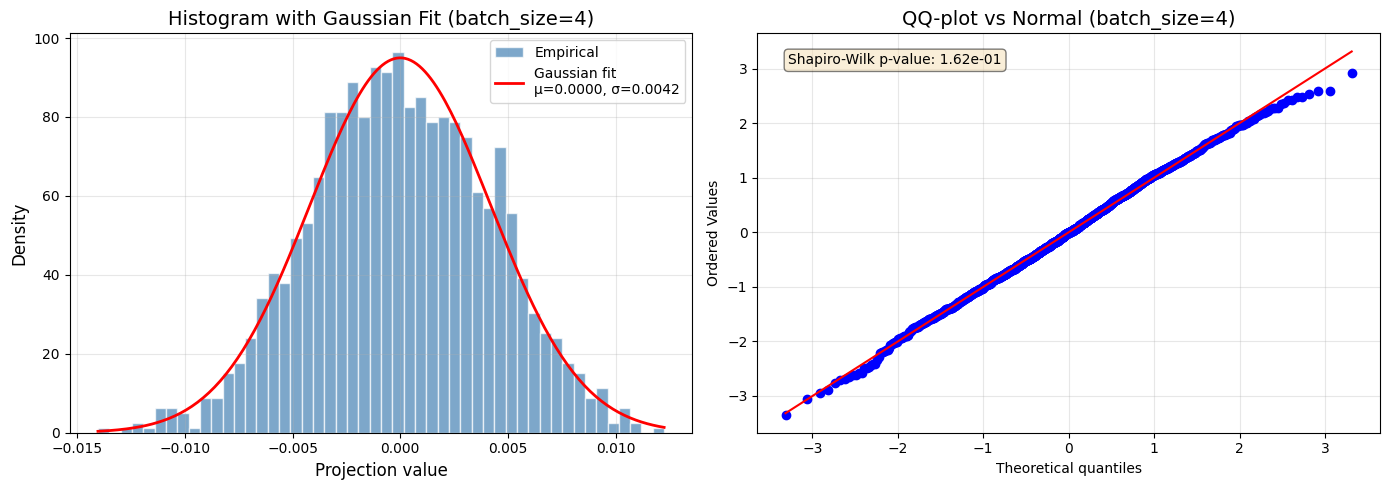

In [20]:
# =============================================================================
# GAUSSIAN DIAGNOSTICS
# =============================================================================

"""
Проверяем гипотезу о гауссовости шума:
1. Гистограмма с Gaussian fit — визуальное сравнение
2. QQ-plot — чувствителен к отклонениям в хвостах
3. Shapiro-Wilk test — формальный статистический тест

Если шум гауссовский:
- Гистограмма должна хорошо аппроксимироваться колоколообразной кривой
- QQ-plot должен быть близок к диагонали
- p-value теста Shapiro-Wilk должен быть > 0.05
"""

mu, sigma = plot_gaussian_diagnostics(
    noise_projections, 
    title_suffix=f"(batch_size={selected_batch_size})"
)

Fitting α-stable distribution (this may take a moment)...
Estimated parameters: α=2.0000, β=1.0000, loc=-0.0000, scale=0.0031


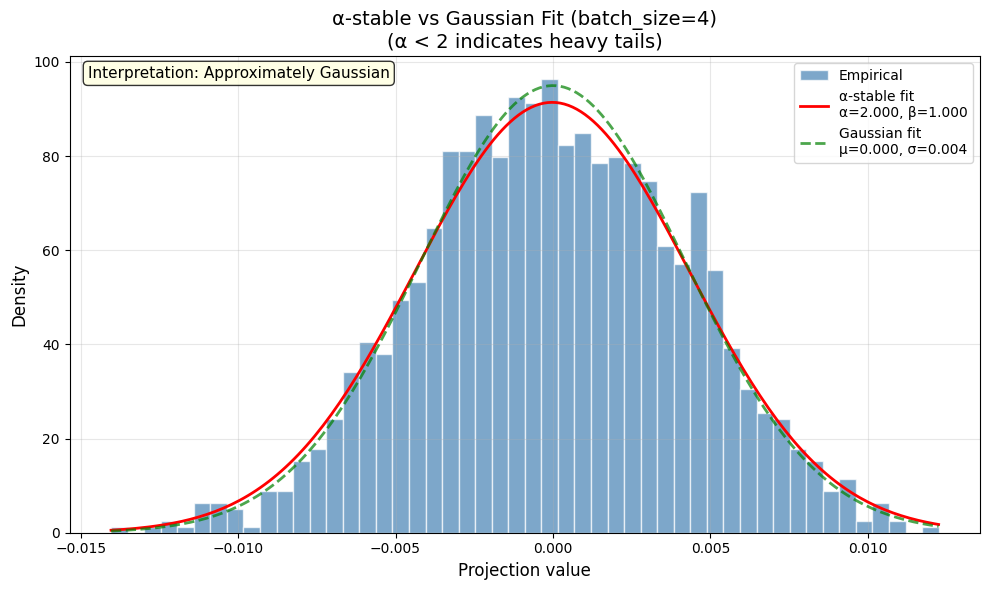


КЛЮЧЕВОЙ РЕЗУЛЬТАТ: α = 2.0000
✓  α ≈ 2 согласуется с гауссовской гипотезой


In [21]:
# =============================================================================
# α-STABLE FIT
# =============================================================================

"""
Аппроксимируем распределение проекций α-stable распределением.

КЛЮЧЕВОЙ РЕЗУЛЬТАТ:
- Если α ≈ 2: шум можно считать гауссовским
- Если α < 2: шум имеет тяжёлые хвосты, гауссовская аппроксимация некорректна

α-stable распределения — единственный класс распределений, устойчивых
относительно суммирования (обобщённая ЦПТ). Это делает их естественным
кандидатом для моделирования шума SGD.
"""

alpha, beta, loc, scale = plot_alpha_stable_fit(
    noise_projections,
    title_suffix=f"(batch_size={selected_batch_size})"
)

print(f"\nКЛЮЧЕВОЙ РЕЗУЛЬТАТ: α = {alpha:.4f}")
if alpha < 1.95:
    print("⚠️  α < 2 указывает на ТЯЖЁЛЫЕ ХВОСТЫ")
    print("   Шум SGD НЕ является гауссовским!")
    print("   Стандартные предположения о сходимости могут нарушаться.")
else:
    print("✓  α ≈ 2 согласуется с гауссовской гипотезой")


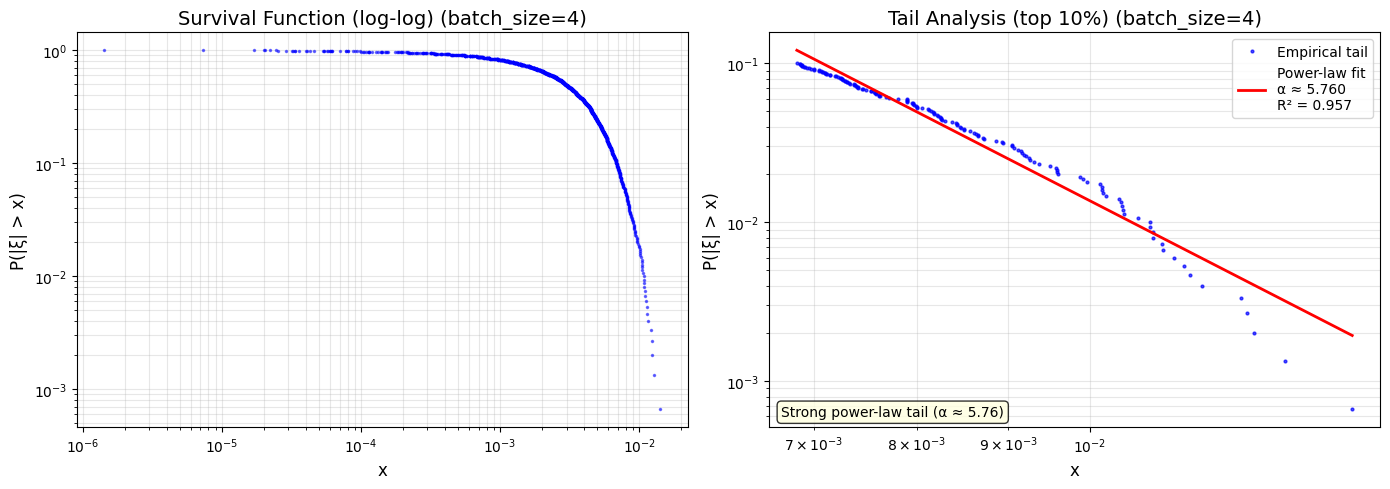


Оценка α по хвосту: 5.7603


In [22]:
# =============================================================================
# АНАЛИЗ ХВОСТОВ (LOG-LOG PLOT)
# =============================================================================

"""
ВИЗУАЛЬНОЕ ДОКАЗАТЕЛЬСТВО ТЯЖЁЛЫХ ХВОСТОВ

Строим log-log график функции выживания P(|ξ| > x).

Интерпретация:
- ЛИНЕЙНЫЙ хвост в log-log → power-law decay → α-stable с α < 2
- ИЗОГНУТЫЙ (параболический) хвост → экспоненциальный decay → Gaussian

Это ключевое визуальное доказательство: если хвост линейный,
то шум НЕ может быть гауссовским.
"""

alpha_tail = plot_tail_loglog(
    noise_projections,
    title_suffix=f"(batch_size={selected_batch_size})"
)

print(f"\nОценка α по хвосту: {alpha_tail:.4f}")


In [23]:
# =============================================================================
# СРАВНЕНИЕ РАЗНЫХ BATCH SIZES
# =============================================================================

"""
Анализируем зависимость α от размера батча.

ТЕОРЕТИЧЕСКОЕ ОЖИДАНИЕ:
- При увеличении batch_size шум должен становиться "более гауссовским" (α → 2)
  из-за ЦПТ (усреднение по большему числу примеров)
- При малых batch_size тяжёлые хвосты более выражены (α < 2)

Это важно для практики: выбор batch_size влияет не только на скорость
сходимости, но и на статистические свойства шума.
"""

results = []

for batch_size in batch_sizes:
    print(f"\n{'='*60}")
    print(f"Batch size = {batch_size}")
    print(f"{'='*60}")
    
    # Берём первую модель для каждого batch_size
    noise_vecs = all_noise_vectors[batch_size][0]
    
    # Проецируем на случайное направление (одинаковое для всех)
    torch.manual_seed(42)
    projections = project_noise(noise_vecs)
    
    # Оцениваем α-stable параметры
    print("Fitting α-stable...")
    try:
        alpha, beta, loc, scale = levy_stable.fit(projections)
        print(f"  α = {alpha:.4f}, β = {beta:.4f}")
    except Exception as e:
        print(f"  Fitting failed: {e}")
        alpha = np.nan
    
    results.append({
        'batch_size': batch_size,
        'alpha': alpha,
        'n_samples': len(projections)
    })

# Визуализация зависимости α от batch_size
import pandas as pd
df_results = pd.DataFrame(results)
print("\n" + "="*60)
print("SUMMARY: α vs batch_size")
print("="*60)
print(df_results.to_string(index=False))



Batch size = 4
Fitting α-stable...
  α = 2.0000, β = 1.0000

Batch size = 16
Fitting α-stable...
  α = 1.9750, β = 0.9998

Batch size = 64
Fitting α-stable...
  α = 2.0000, β = 1.0000

SUMMARY: α vs batch_size
 batch_size    alpha  n_samples
          4 2.000000       1500
         16 1.974989        375
         64 2.000000         94


In [ ]:
# =============================================================================
# ВИЗУАЛИЗАЦИЯ: α vs BATCH SIZE
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_results['batch_size'], df_results['alpha'], 'bo-', markersize=10, linewidth=2)
ax.axhline(y=2, color='r', linestyle='--', linewidth=2, label='Gaussian (α = 2)')

ax.set_xlabel('Batch Size', fontsize=14)
ax.set_ylabel('Stability Index α', fontsize=14)
ax.set_title('Dependence of α on Batch Size\n(α < 2 indicates heavy tails)', fontsize=16)
ax.set_xscale('log', base=2)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Аннотации
for _, row in df_results.iterrows():
    ax.annotate(f"α={row['alpha']:.2f}", 
                (row['batch_size'], row['alpha']),
                textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
# =============================================================================
# МНОЖЕСТВЕННЫЕ ПРОЕКЦИИ (РОБАСТНОСТЬ)
# =============================================================================

"""
Проверяем, что результат не зависит от выбора направления проекции.

Для изотропного распределения (или распределения с изотропной ковариацией)
α должен быть одинаковым для всех направлений.

Если α существенно различается для разных направлений, это указывает
на анизотропию шума.
"""

n_projections = 10
alphas_multiple = []

selected_noise = all_noise_vectors[16][0]  # batch_size=16, model 0

for i in range(n_projections):
    torch.manual_seed(i * 100)  # Разные направления
    proj = project_noise(selected_noise)
    
    try:
        alpha_i, _, _, _ = levy_stable.fit(proj)
        alphas_multiple.append(alpha_i)
        print(f"Projection {i+1}: α = {alpha_i:.4f}")
    except:
        print(f"Projection {i+1}: fitting failed")

print(f"\nМean α across projections: {np.mean(alphas_multiple):.4f} ± {np.std(alphas_multiple):.4f}")


In [ ]:
# =============================================================================
# СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# =============================================================================

import pickle

# Сохраняем векторы шума (не нормы!)
save_data = {
    'noise_vectors': all_noise_vectors,
    'batch_sizes': batch_sizes,
    'alpha_results': df_results.to_dict(),
    'metadata': {
        'description': 'Vectorial noise of stochastic gradient (not norms!)',
        'methodology': 'Noise = stochastic_grad - full_grad, stored as flatten vectors',
        'analysis': 'One-dimensional projections used for statistical tests',
        'dataset': 'MNIST',
        'model': 'MLP',
        'model_config': MODEL_CONFIG,
        'sample_size': SAMPLE_SIZE
    }
}

with open(f"{OUTPUT_DIR}/exp6_noise_vectors.pkl", "wb") as f:
    pickle.dump(save_data, f)

print(f"Results saved to {OUTPUT_DIR}/exp6_noise_vectors.pkl")


# Выводы

## Методологические замечания

1. **Анализ нормы градиентного шума методологически некорректен** для проверки гауссовости:
   - Норма многомерного гауссовского вектора имеет χ-распределение, а не Gaussian
   - Норма уничтожает информацию о хвостах распределения отдельных компонент
   - Невозможно корректно оценить индекс устойчивости α из распределения нормы

2. **Корректный подход — анализ одномерных проекций** шума на случайные направления:
   - По теореме Крамера-Вольда, проекции гауссовского вектора также гауссовские
   - Проекции α-stable вектора также α-stable с тем же α
   - Это позволяет применять одномерные статистические тесты

## Теоретический контекст

**α-stable распределения** — единственный класс распределений, устойчивых относительно суммирования (обобщённая ЦПТ):
- α = 2 соответствует Gaussian распределению (конечная дисперсия)
- α < 2 означает тяжёлые хвосты с power-law decay: P(|X| > x) ~ x^{-α}
- При α < 2 дисперсия бесконечна

**Следствия для SGD при α < 2:**
- Стандартные предположения о сходимости нарушаются
- Требуются модифицированные оценки скорости сходимости
- Шум SGD не может быть аппроксимирован гауссовской диффузией
- Динамика SGD описывается процессом Леви, а не броуновским движением
